# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P2-01: ECG-Fitness Preprocessing

### What this notebook does

This notebook preprocesses the **ECG-Fitness dataset** into a unified HDF5 format that is compatible with all other datasets in the QualityPhys pipeline.

ECG-Fitness is the most technically challenging dataset in project corpus because:
- Videos are stored in **YUV 4:2:0 format**  - OpenCV auto-decodes to BGR,
- Ground truth is **2-lead ECG** (not PPG) - requires a separate R-peak detection pipeline and yields more accurate HRV than any PPG-based dataset
- Subjects perform **physical exercise** - wide HR range (56-159 BPM), strong periodic motion artefact from mrowing strokes and pedalling cycles
- Two lighting conditions - **halogen activities (03, 04) are excluded** due to 50 Hz flicker aliasing into the rPPG bandpass at 3.33 Hz

### Known dataset limitations

Face detection fails completely for some subjects across all activities, likely due to face angle or apperance outside MediaPipe's training distribution. These subjects are excluded and documented in the processing log.

Several recordings were captured in low ambient light (late afternoon or night sessions). Cameras compensate using automatic gain control (AGC), which amplifies sensor noise alongside the signal and reduces the rPPG signal-to-noise ratio to unusable levels. These recordings are detected by a brightness per-screen and excluded before the main pipeline runs, with the reason logged explicitly as `low_light` for traceablity.

### Dataset structure reminder
```
ECG-Fitness/
├── XX/          ← subject ID (00–16, 17 subjects total)
│   └── YY/      ← activity ID
│       ├── c920-1.avi <- tripod camera 
│       ├── c920-2.avi <- machine-mounted camera  (not used in this project)
│       ├── c920.csv <- per-frame index into ECG signal (sync key)
│       └── viatom-raw.csv <- ECG + HR + SpO2 from Viatom device
└── bbox/ <- pre-computed face bounding boxes (optional)
```

### Activities
| ID | Activity | Lighting | Include? | Reason |
|----|----------|----------|---------|---------|
| 01 | Rowing | Ambient | ✅ | |
| 02 | Speaking | Ambient | ✅ | |
| 03 | Rowing | Halogen 50 Hz | ❌ | Flicker artefact at 3.33 Hz |
| 04 | Speaking | Halogen 50 Hz | ❌ | Flicker artefact at 3.33 Hz |
| 05 | Elliptical trainer | Ambient | ✅ |
| 06 | Stationary bike | Ambient | ✅ |

### Pipeline (what this notebook builds step by step)

```
c920-1.avi (BGR decoded by OpenCV)
    │
    ├─ 1. BGR -> RGB conversion
    ├─ 2. MediaPipe face detection -> ROI extraction (forehead, cheeks)
    └─ 3. Spatial mean RGB per ROI -> raw colour signal [T, 3_ROIs, 3_ch]
           │
           └─ 4. Bandpass filter 0.7–3.5 Hz -> POS extraction -> rPPG signal [T]

viatom-raw.csv (ECG column 2)
    │
    ├─ 5. Bandpass filter 0.5–40 Hz (ECG range)
    ├─ 6. R-peak detection (NeuroKit2)
    └─ 7. Compute HR, RR intervals, RMSSD

c920.csv (sync)
    │
    └─ 8. Align ECG samples to video frames

9. Signal Quality Index (rPPG SQI + ECG SQI)
10. Discard low-quality clips
11. Write to HDF5
```


## 1. Environment Setup

In [1]:
# Install required libraries
import subprocess, sys

packages = [
    "neurokit2", # ECG/PPG signal processing and peak detection
    "mediapipe", # Face mesh for ROI extraction
    "h5py", # HDF5 file reading and writing
    "opencv-python", # Video reading and YUV->RGB conversion
    "scipy", # Butterworth bandpass filter
    "numpy",
    "pandas",
    "matplotlib"
    ]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("All packeges installed")

All packeges installed


## 2. Imports and Configuration

In [2]:
import os, warnings, cv2, h5py, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from scipy.signal import butter, filtfilt
warnings.filterwarnings("ignore")

# Plot style
plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor" : "#1a1a2e",
    "axes.edgecolor" : "#444444",
    "axes.labelcolor" : "#e0e0e0",
    "xtick.color" : "#e0e0e0",
    "ytick.color" : "#e0e0e0",
    "text.color" : "#e0e0e0",
    "grid.color" : "#2a2a3e",
    "grid.linestyle" : "--",
    "grid.alpha" : 0.5,
    "figure.dpi" : 110,
})

# Dataset name
DATASET_NAME = "ecg_fitness"

# Paths
ECG_FITNESS_DIR = "F:/ECG_Fitness_Raw/ecg-fitness_raw-v1.0"
OUTPUT_DIR = "E:/QualityPhys"
os.makedirs(OUTPUT_DIR, exist_ok=True)
HDF5_PATH = os.path.join(OUTPUT_DIR, "ecg_fitness.h5")
# Activity configuration
# Activities 03 and 04 use halogen lighting which causes 50Hz flicker.
# At 30 fps this aliases to 3.33 Hz - inside our rPPG bandpass (0.7-3.5 Hz).
# Including them would contaminate the rPPG signal with lighting artefact.
VALID_ACTIVITIES = ["01", "02", "05", "06"]
ACTIVITY_NAMES = {
    "01" : "rowing_ambient",
    "02" : "speaking_ambient",
    "05" : "elliptical_ambient",
    "06" : "bike_ambient"
}



# Camera selection
# c920-1.avi - tripod-mounted, frontal view -> consistent face angle
# c920-2.avi - machine-mounted -> non-frontal, excluded
CAMERA_FILE = "c920-1.avi"

# Signal processing parameters
FPS = 30.0 # ECG-Fitness video frame rate 

# rPPG bandpass: 0.7-3.5 Hz = 42-210 BPM
# Lower bound 0.7 Hz removes: breathing drift, slow illumination changes
# Upper bound 3.5 Hz removes: motion noise, camera sensor noise
RPPG_BP_LOW = 0.7
RPPG_BP_HIGH = 3.5 

# ECG bandpass: 0.5-40 Hz - standard clinical ECG processing range
# Lower bound 0.5 Hz removes: baseline wander (patient breathing, movement)
# Upper bound 40 Hz removes: high-frequency electrical noise (mains, muscle)
# Why wider than rPPG? ECG QRS complex has fast componets up to ~30-40 Hz
# The rPPG signal is much slower - it only needs a nerrow physiological band
ECG_BP_LOW = 0.5
ECG_BP_HIGH = 40.0

# Signal Quality Index thresholds
# Clips below these thresholds are discarded entirely (not stored as NaN)
RPPG_SQI_THRESHOLD = 0.4 # autocorrelation-based quality score
ECG_SQI_THRESHOLD = 0.5 # R-peak regularity score

# ROI landmark indices (MediaPipe Face Mesh, 468-point model)
FOREHEAD_LM = [10, 338, 297, 332, 284, 251, 389, 356, 454,
                  323, 361, 288, 397, 365, 379, 378, 400, 377,
                  152, 148, 176, 149, 150, 136, 172, 58, 132,
                  93, 234, 127, 162, 21, 54, 103, 67, 109]

LEFT_CHEEK_LM = [234, 227, 116, 123, 147, 213, 192, 214, 210,
                 211, 206, 203, 36, 101, 119, 229, 228]

RIGHT_CHEEK_LM = [454, 447, 345, 352, 376, 433, 416, 434, 430,
                  431, 426, 423, 266, 330, 348, 449, 448]

ROI_CONFIGS = {
    "forehead" : FOREHEAD_LM,
    "left_cheek" : LEFT_CHEEK_LM,
    "right_cheek" : RIGHT_CHEEK_LM
}

# Brightness per-screening threshold
# Mean pixel brightness of the forehead ROI across the first 10 frames.
# Brightness is measured on a 0-255 scale (8-bit RGB).
# Recordings below this threshold are in low-light conditions where AGC 
# amplifies noise alongside signal, making rPPG extraction unreliable.
# These are skipped early - before MediaPipe and POS extraction run - to save 
# processing time and produce a more informative skip reason.
# Empirically calibrated: well-lit indoor recordings typically exceed 80.
# Late afternoon / night recordings in ECG-Fitness fall below 40-50.
MIN_BRIGHTNESS = 25

print("Configuration loaded.")
print(f"Dataset path : {ECG_FITNESS_DIR}")
print(f"Output HDF5 : {HDF5_PATH}")
print(f"Output path : {OUTPUT_DIR}")
print(f"Valid activities: {VALID_ACTIVITIES}")
print(f"rPPG bandpass: {RPPG_BP_LOW}-{RPPG_BP_HIGH} Hz ({RPPG_BP_LOW*60:.0f}-{RPPG_BP_HIGH*60:.0f} BPM)")
print(f"ECG bandpass: {ECG_BP_LOW}-{ECG_BP_HIGH} Hz")

    

Configuration loaded.
Dataset path : F:/ECG_Fitness_Raw/ecg-fitness_raw-v1.0
Output HDF5 : E:/QualityPhys\ecg_fitness.h5
Output path : E:/QualityPhys
Valid activities: ['01', '02', '05', '06']
rPPG bandpass: 0.7-3.5 Hz (42-210 BPM)
ECG bandpass: 0.5-40.0 Hz


In [3]:
def check_recording_brightness(video_path: str, n_frames: int = 10, roi_fraction: float = 0.3) -> float:
    """
    Quick brightness per-screen before running the full pipeline.

    Rather than running MediaPipe face detection (slow), 
    a simple centre-fraction of the frame as a proxy for the face region is being used.
    This is approximate but fast - there is only need to distinguish 'clearly too dark'
    from 'probably usable', not precisely locate the face.

    The centre fraction works because ECG-Fitness uses a tripod-mounted frontal camera (c920-1.avi)
    the face is always roughly centered.

    Args:
        video_path : path to the video file
        n_frames : number of frames to sample (default 10 - fast)
        roi_fraction : fraction of frame height/width to use as centre crop 
                       (default 0.3 = central 30 % of the frame)

    Returns: 
        mean brightness (0-255 scale), or 0.0 if video cannot be opened.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return 0.0

    # Skip frame 0 as required by dataset documentation 
    cap.read()

    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

    # Define centre crop boundaries
    y1 = int(h * (0.5 - roi_fraction / 2 ))
    y2 = int(h * (0.5 + roi_fraction / 2 ))
    x1 = int(w * (0.5 - roi_fraction / 2 ))
    x2 = int(w * (0.5 + roi_fraction / 2 ))

    brightness_values = []
    frames_read = 0

    while frames_read < n_frames:
        ret, frame = cap.read()
        if not ret:
            break 
        # Convert to RGB and crop to centre region
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        centre_crop = rgb[y1:y2, x1:x2]
        # Mean brightness = mean of all pixel values across all channels
        brightness_values.append(centre_crop.mean())
        frames_read += 1
    
    cap.release()

    if not brightness_values:
        return 0.0

    return float(np.mean(brightness_values))

## 3. Dataset Scan

Before processing anything, scan the dataset directory and build an inventory of all valid recordings. This catches missing files early rather than discovering them halfway through a long processing run.

**Expected structure per recording:**

`XX/YY/c920-1.avi <- video we process`
`XX/YY/c920.csv <- sync file (frame -> ECG sample index)`
`XX/YY/viatom-raw.csv <- ECG + HR from Viatom device`

**Two known missing recordings (from the dataset manual):**
* Subject 02, activity 04 - missing for all cameras
* Subject 07, activity 02 - missing for all cameras. These are not errors - they are documented absences.


In [4]:
def scan_ecg_fitness(root_dir: str, valid_activities: list) -> pd.DataFrame:
    """
    Walk the ECG-Fitness directory tree and build an inventory
    of all valid recordings.

    Returns a DataFrame with one row per recording, containing
    paths to all required files and basic metadata.
    """
    records = []

    # Walk through subject folders (00-16)
    for subject_folder in sorted(os.listdir(root_dir)):
        subject_path = os.path.join(root_dir, subject_folder)
        if not os.path.isdir(subject_path):
            continue

        # Try to parse subject ID as integer
        try:
            subject_id = int(subject_folder)
        except ValueError:
            continue

        # Walk through activity folders
        for activity_folder in sorted(os.listdir(subject_path)):
            if activity_folder not in valid_activities:
                continue # skip halogen activities 03 and 04

            activity_path = os.path.join(subject_path, activity_folder)

            # Build paths to required files
            video_path = os.path.join(activity_path, "c920-1.avi")
            sync_path = os.path.join(activity_path, "c920.csv")
            viatom_path = os.path.join(activity_path, "viatom-raw.csv")

            # Check all three files exist
            has_video = os.path.exists(video_path)
            has_sync = os.path.exists(sync_path)
            has_viatom = os.path.exists(viatom_path)

            records.append({
                "subject_id" : subject_id,
                "subject_folder" : subject_folder,
                "activity_id" : activity_folder,
                "activity_name" : ACTIVITY_NAMES.get(activity_folder, "unknown"),
                "video_path" : video_path if has_video else None,
                "sync_path" : sync_path if has_sync else None,
                "viatom_path" : viatom_path if has_viatom else None,
                "complete" : has_video and has_sync and has_viatom,
            })
    return pd.DataFrame(records).sort_values(["subject_id", "activity_id"]).reset_index(drop=True)

# Run the scan
df_inventory = scan_ecg_fitness(ECG_FITNESS_DIR, VALID_ACTIVITIES)

# Summary
complete = df_inventory["complete"].sum()
incomplete = (~df_inventory["complete"]).sum()
print(f"Recordings found: {len(df_inventory)}")
print(f"Complete : {complete}")
print(f"Incomplete : {incomplete} (expected: 2 documented missing recordings)")
print()
print(df_inventory[["subject_id", "activity_id", "activity_name", "complete"]].to_string(index=False))

Recordings found: 68
Complete : 68
Incomplete : 0 (expected: 2 documented missing recordings)

 subject_id activity_id      activity_name  complete
          0          01     rowing_ambient      True
          0          02   speaking_ambient      True
          0          05 elliptical_ambient      True
          0          06       bike_ambient      True
          1          01     rowing_ambient      True
          1          02   speaking_ambient      True
          1          05 elliptical_ambient      True
          1          06       bike_ambient      True
          2          01     rowing_ambient      True
          2          02   speaking_ambient      True
          2          05 elliptical_ambient      True
          2          06       bike_ambient      True
          3          01     rowing_ambient      True
          3          02   speaking_ambient      True
          3          05 elliptical_ambient      True
          3          06       bike_ambient      True
    

## 4. BGR -> RGB Conversion

### Why ECG-Fitness needs explicit conversion - and what actually happens

All other dataset in project pipeline (UBFC-rPPG, UBFC-Phys, PURE, MCD-rPPG) store videos as uncompressed 8-bit RGB. ECG-Fitness was orginally recorded in  **YUV 4:2:0 planar format** - a common broadcast/webcam  encoding that reduces file size by subsampling  colour information.

However, **OpenCV handles the YUV decoding automatically and transparently** when reading the video file with `cv2.VideoCapture`. By the time a frame reaches your Python code, it has already been converted to a standard 3-channels BGR image. This means the `cv2.COLOR_YUV2RGB_I420` flag is not needed and will actually crash with a channel mismatch error, because the frame is already BGR (3 channels) not raw YUV planar data (1 channel).

The only conversion we need to apply explicitly is **BGR -> RGB**, which simply swaps the red and blue channels. OpenCV stores colour images in BGR order by convention (a historical quirk from its early Windows development), while MediaPipe and most other libraries expect RGB. One line handles this 

```python
rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
```
  
The original YUV 4:2:0 format separates luminance from colour information. The Y channel carries brightness at full resolution, while the U and V channels carry colour at half spatial resolution due to 4:2:0 subsampling. This matters for rPPG in principle because our pulse signal lives in the colour channels - but since OpenCV upsamples the colour channels back to full resolution during decoding, and since we spatially average over hundreds of pixels per ROI anyway, the subsampling has negligible impact on our extracted signal.

#### Verify visually before processing

Always plot a converted frame before running the full pipeline. If the colour channels are in the wrong order, skin tones will appear blue-tinted rather than natural - and every ROI colour mean extracted downstream will be wrong.
  

Checking: Subject 0 Activity: 01 (rowing_ambient)



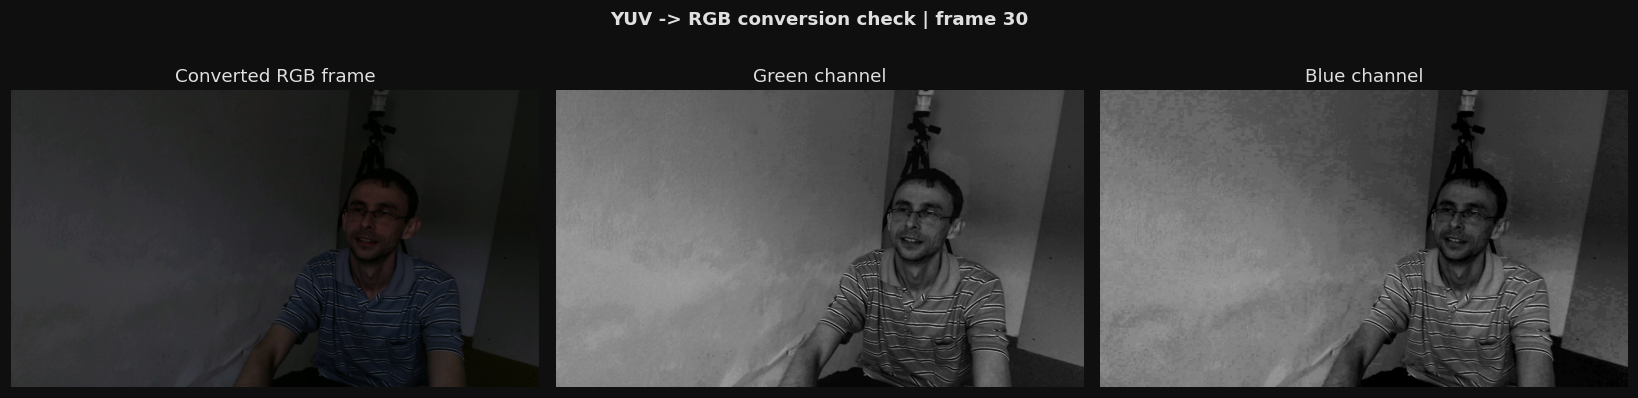

Mean pixel values - R: 35.9 G: 36.4 B: 37.5
Expected: values roughly similar across channels for a natural scene
Red flag: one channel >> others suggest wrong conversion flag


In [5]:
def read_yuv_frame_as_rgb(cap: cv2.VideoCapture) -> np.ndarray | None:
    """
    Read one frame from a YUV 4:2:0 video and convert to RGB.

    ECG-Fitness notes:
        - Videos are stored in YUV planar format
        - 4:2:0 chroma subsampling was applied by the c920 camera hardware before
        USB transmission - this is a hardware limitation, not a software choice
        - cv.COLOR_BGR2RGB is the correct flag for 4:2:0 planar format

    Returns None if no frame is available (end of video).
    """
    ret, frame = cap.read()
    if not ret:
        return None

    # OpenCV reads the file as-is (YUV planar bytes)
    # Exact format must be provided to convert it correctly
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return rgb_frame

def verify_yuv_conversion(video_path: str, frame_idx: int = 30) -> None:
    """
    Visual sanity check - display a converted frame.

    What a correct conversion looks like:
        - Natural skin tones 9not green-tined, not red-shifted)
        - Clear facial features visible
        - No horizontal banding artefacts

    What a wrong conversion flag looks like:
        - Strong green or magneta cast
        - Scrambled pixel layout
        - Half the image is grey
    """
    cap = cv2.VideoCapture(video_path)

    # Skip to the target frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    rgb_frame = read_yuv_frame_as_rgb(cap)
    cap.release()

    if rgb_frame is None:
        print(f"Could not read frame {frame_idx} from {video_path}")
        return

    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    fig.suptitle(f"YUV -> RGB conversion check | frame {frame_idx}", fontsize=12, fontweight="bold")

    # Full RGB frame
    axes[0].imshow(rgb_frame)
    axes[0].set_title("Converted RGB frame")
    axes[0].axis("off")

    # Individual channels - help spot conversion errors
    channel_names = ["Red channel", "Green channel", "Blue channel"]
    for i, (ax, name) in enumerate(zip(axes[1:], channel_names[1:])):
        # Show only G and B to avoid crowding
        ax.imshow(rgb_frame[:, :, i+1], cmap="grey")
        ax.set_title(name)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/yuv_conversion_check.png", bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    # Pixel value sanity check
    mean_r = rgb_frame[:, :, 0].mean()
    mean_g = rgb_frame[:, :, 1].mean()
    mean_b = rgb_frame[:, :, 2].mean()
    print(f"Mean pixel values - R: {mean_r:.1f} G: {mean_g:.1f} B: {mean_b:.1f}")
    print("Expected: values roughly similar across channels for a natural scene")
    print("Red flag: one channel >> others suggest wrong conversion flag")

# Run on first complete recording
first_recording = df_inventory[df_inventory["complete"]].iloc[0]
print(f"Checking: Subject {first_recording.subject_id} Activity: {first_recording.activity_id} ({first_recording.activity_name})")
print()
verify_yuv_conversion(first_recording["video_path"])

## 5. Load and Inspect ECG Signal

### The Viatom CSV structure

`viatom-raw.csv` has 7 columns - but only the first 3 were actually recorded:

| column | Content| Recorded?|
|--------|--------|----------|
| 0 | System time (ms) | ✅ |
| 1 | **Raw ECG signal** | ✅ <- this is what we use |
| 2 | HR computed by Viatom device | ✅ <- cross-check for our R-peak detection |
| 3-6 | PPG, computed PPG HR, SPO2, PI | ❌ not recorded |

**Important:** The Viatom device computes its own HR from the ECG internally.
After detection of R-peak, comparision is being made with our HR estimate against the device HR (column2).
If they disagree significantly, something went wrong.

### The sync file (c920.csv)

`c920.cvs` maps each video frame to an ECG sample index.
Line k -> frame k -> ECG sample index for that frame.

This is a per-frame index lookup, not a timestamp calculation.
It's the most precise synchronisation of any dataset in our pipeline.

### First frame warning

The dataset manual explicitly states: **"The first frame of every video must not be used."** Frame ) has been skipt for all processing.



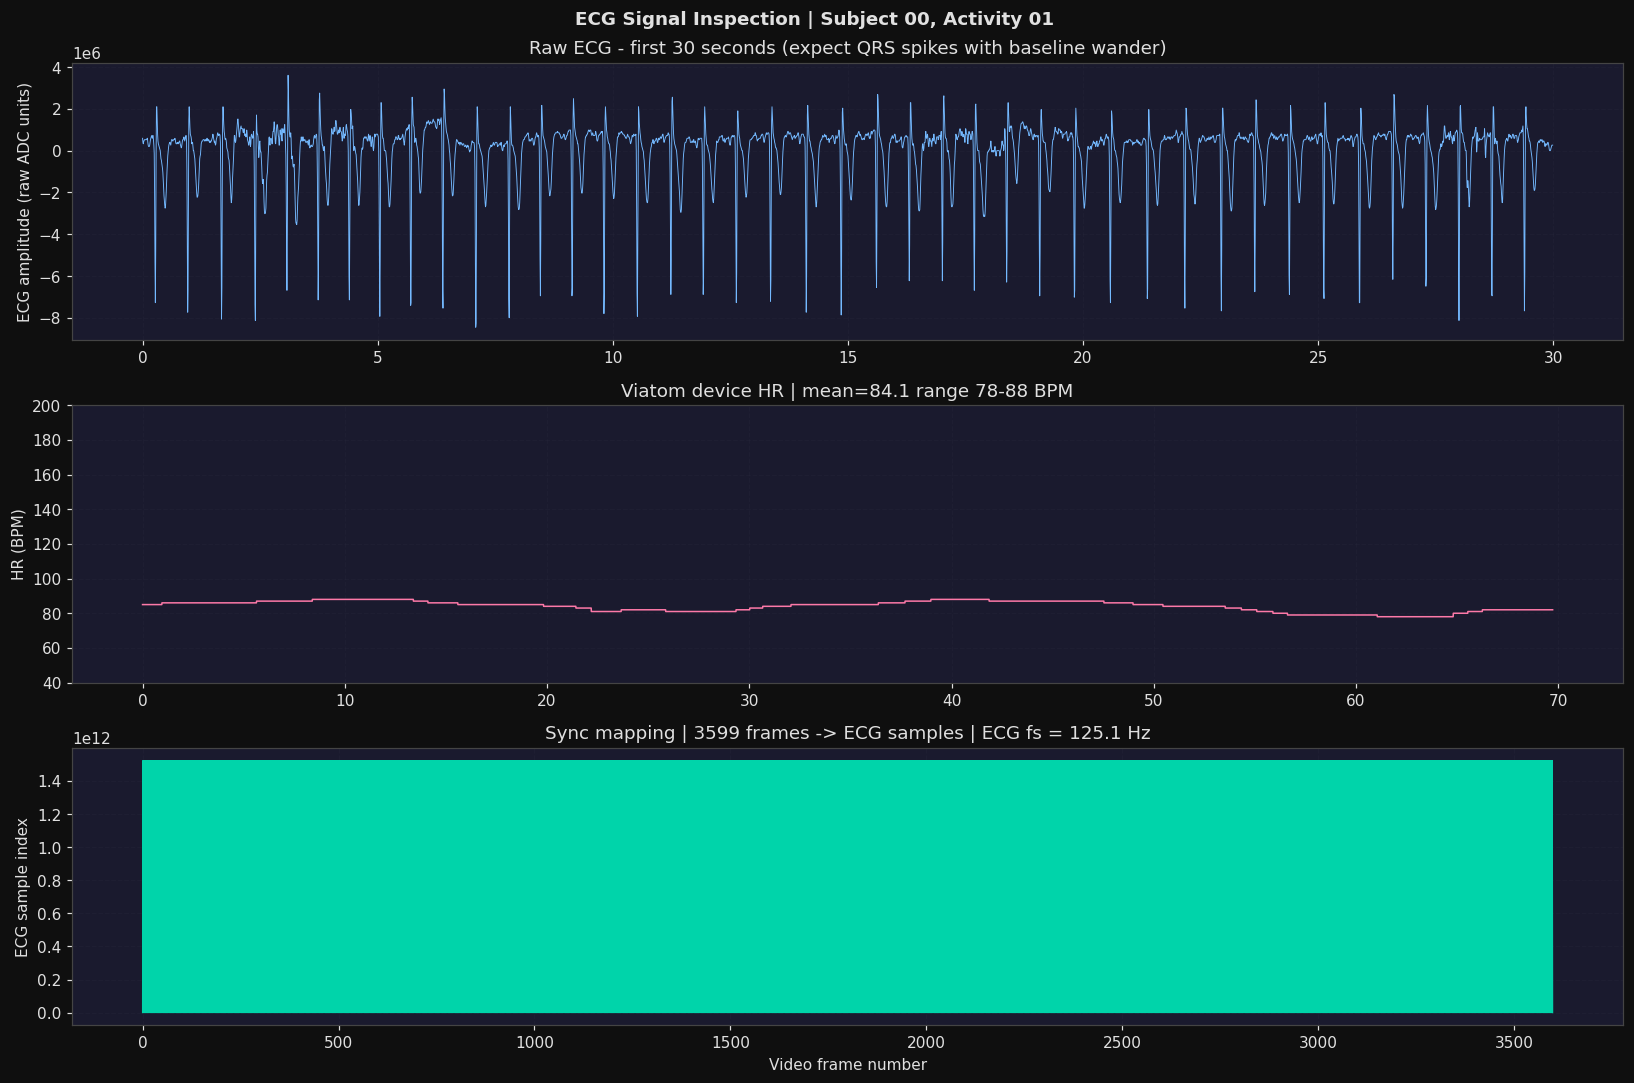

ECG sampling rate : 125.1 Hz
ECG duration : 69.7 s
Video frames : 3599
Signal amplitude : min=-8847360.0 max=3604480.0

✅ Signal amplitude OK (12451840 ADC units range)


In [6]:
def load_viatom_ecg(viatom_path: str) -> pd.DataFrame:
    """
    Load the Viatom device CSV.

    Returns a DataFrame with columns:
        time_ms : system timestamp in milliseconds
        ecg_raw : raw ECG sugnal (column 1)
        hr_device : HR computed by the Viatom device (column 2)

    Only the first 3 columns were recorded - the rest are zeros/empty.
    We load only what we need.
    """
    # The file has a header row
    df = pd.read_csv(viatom_path, header=0, usecols=[0, 1, 2], names=["time_ms", "ecg_raw", "hr_device"])

    # Drop any rows with NaN
    df = df.dropna().reset_index(drop=True)

    return df

def load_sync_file(sync_path: str) -> np.ndarray:
    """
    Load c920.csv - the per frame ECG sample index.
    
    Line k contains the Viatom sample index corresponding to frame k.
    frame 0 is being skipped(as per dataset manual) by dropping index 0.

    Returns array of ECG sample indices, one per video frame (exluding frame 0).
    """
    sync = pd.read_csv(sync_path, header=None).values.flatten().astype(int)

    # Skip first frame as required by dataset documentation 
    return sync[1:]

def inspect_ecg_signal(viatom_path: str, sync_path: str, subject_id: int, activity: str) -> None:
    """
    Visual inspection of the raw ECG signal for one recording.

    Plots:
        1. Raw ECG (before filtering) - should show QRS complexes with baseline wander
        2. HR from Viatom device - should show physicologically plausible values
        3. Sync file - frame-to-ECG-sample mapping

    What you are looking for clinically:
        - Clear QRS spikes visible in the raw signal
        - HR range appropriate for the activity (exercise: 80-160 BPM)
        - No completely flat sections (disconnected electrode)
        - No saturation (signal clipped at a constant max value)
    """
    df_viatom = load_viatom_ecg(viatom_path)
    sync = load_sync_file(sync_path)

    ecg_raw = df_viatom["ecg_raw"].values.astype(np.float32)
    hr_device = df_viatom["hr_device"].values.astype(np.float32)

    # Estimate ECG sampling rate from timestamps
    dt_ms = np.diff(df_viatom["time_ms"].values).mean()
    ecg_fs = 1000.0 / dt_ms # Hz
    t_ecg = np.arange(len(ecg_raw)) / ecg_fs # time axis in seconds

    fig, axes = plt.subplots(3, 1, figsize=(15, 10))
    fig.suptitle(f"ECG Signal Inspection | Subject {subject_id:02d}, Activity {activity}",
                fontsize=12, fontweight="bold")

    # Raw ECG
    ax = axes[0]
    ax.plot(t_ecg[:int(ecg_fs*30)], ecg_raw[:int(ecg_fs*30)], color="#74b9ff", lw=0.6)
    ax.set_ylabel("ECG amplitude (raw ADC units)")
    ax.set_title("Raw ECG - first 30 seconds (expect QRS spikes with baseline wander)")
    ax.grid(True, alpha=0.3)

    # Device HR 
    ax = axes[1]
    t_hr = np.arange(len(hr_device)) / ecg_fs
    valid_hr = hr_device[hr_device > 0] # device outputs 0 when computing
    ax.plot(t_hr, hr_device, color="#fd79a8", lw=1.0)
    ax.set_ylabel("HR (BPM)")
    ax.set_title(f"Viatom device HR | mean={valid_hr.mean():.1f} range {valid_hr.min():.0f}-{valid_hr.max():.0f} BPM")
    ax.set_ylim(40, 200)
    ax.grid(True, alpha=0.3)

    # Sync mapping 
    ax = axes[2]
    ax.plot(np.arange(len(sync)), sync - sync[0], color="#00d4aa", lw=0.8)
    ax.set_ylabel("ECG sample index")
    ax.set_xlabel("Video frame number")
    ax.set_title(f"Sync mapping | {len(sync)} frames -> ECG samples | ECG fs = {ecg_fs:.1f} Hz")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/ecg_inspect_s{subject_id:02d}_a{activity}.png",
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    # Numerical summary
    print(f"ECG sampling rate : {ecg_fs:.1f} Hz")
    print(f"ECG duration : {len(ecg_raw)/ecg_fs:.1f} s")
    print(f"Video frames : {len(sync)}")
    print(f"Signal amplitude : min={ecg_raw.min():.1f} max={ecg_raw.max():.1f}")
    print()

    # Flat signal check - a flat ECG means disconnected electrode
    amplitude_range = ecg_raw.max() - ecg_raw.min()
    if amplitude_range < 40:
        print("WARNING: Very low amplitude - possible electrode disconnection")
    else:
        print(f"✅ Signal amplitude OK ({amplitude_range:.0f} ADC units range)")

    return ecg_fs

# Inspect first complete recording
ecg_fs_detected = inspect_ecg_signal(
    first_recording["viatom_path"],
    first_recording["sync_path"],
    first_recording["subject_id"],
    first_recording["activity_id"]
)

## 6. ECG Bandpass Filter

### Why ECG needs a different filter than rPPG

In Phase 1 for rPPG singals bandpass 0.7-3.5 Hz were used. ECG needs a much wider band: **0.5-40 Hz.**

The reason is the QRS comples. When you read an ECG clinically, the sharp spike of the R-wave looks instantaneous - but it actually contains frequency components up to ~40 Hz. If you filtered ECG the same way as rPPG (cutting at 3.5 Hz), you would remove most of the R-wave energy and R-peak detection would fail.

Think of it this way: the rPPG signal is a slow sinusoid (one gentle bump per heartbeat). The ECG R-wave is a fast, narrow spike. Fast spikes requre high frequencies to represent accurately - that's why we keep up to 40 Hz.

**What each cutoff removes:**

* **0.5 Hz lower cutoff** -> removes baseline wander (the slow drift you see when a patient breathes or move)
* **40 Hz upper cutoff** -> removes electrical mains noise (50/60 Hz), electromyographic noise from muscles, and high-frequency sensor noise.

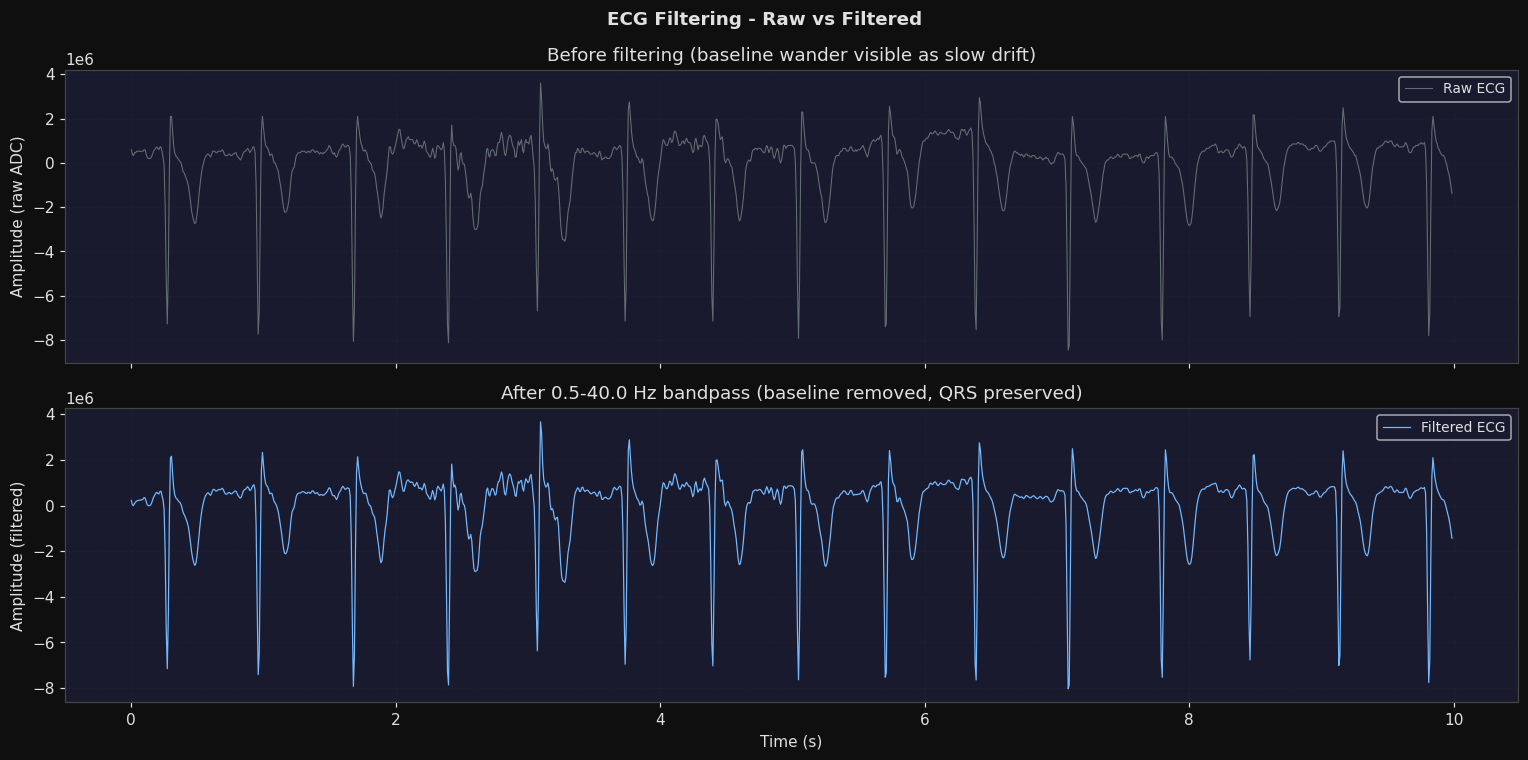

Filtered ECG shape : (8720,)
Mean (should be ≈0) : -1426.1101


In [7]:
def bandpass_filter(signal: np.ndarray, fs: float, low: float, high: float, order: int = 2) -> np.ndarray:
    """
    Zero-phase Butterworth bandpass filter.

    Zero-phase means the filter is applied forward then backward (filtfilt).
    This preserves the timing of peaks - critical for both ECG R-peak detection
    and rPPG HRV computation where a 10ms timing error changes RMSSD significantly.

    The same function works for both ECG (0.5 - 40 Hz) and rPPG (0.7 - 3.5 Hz)
    because only  the cutoff frequencies differ, not the alorithm.

    Args:
        signal : 1D array
        fs : sampling frequency in Hz
        low : lower cutoff in Hz
        high : upper cutoff in Hz
        order : filter steepness (2 = gentle, avoids ringing artefacts)
    """
    nyq = fs / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal).astype(np.float32)

def visualise_filtering(ecg_raw: np.ndarray, ecg_fs: float, window_sec: float = 10.0) -> np.ndarray:
    """
    Plot raw vs filtered ECG side by side.

    What good filtering looks like:
        - Baseline wander (slow drift) removed - trace is centered around zero
        - QRS spikes are preserved - sharp peaks still present
        - No new oscillations introduced by the filter (ringing artefacts)

    What bad filtering looks like:
        - QRS peaks are rounded or reduced in amplitude (filter too aggresive)
        - Oscillations appear before/after each QRS (Gibbs - phenomenon - caused by too high a filter order)
    """
    ecg_filtered = bandpass_filter(ecg_raw, ecg_fs, low=ECG_BP_LOW, high=ECG_BP_HIGH)
    n_show = int(window_sec * ecg_fs)
    t = np.arange(n_show) / ecg_fs

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle("ECG Filtering - Raw vs Filtered", fontsize=12, fontweight="bold")

    axes[0].plot(t, ecg_raw[:n_show], color="#636e72", lw=0.7, label="Raw ECG")
    axes[0].set_ylabel("Amplitude (raw ADC)")
    axes[0].set_title("Before filtering (baseline wander visible as slow drift)")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, ecg_filtered[:n_show], color="#74b9ff", lw=0.8, label="Filtered ECG")
    axes[1].set_ylabel("Amplitude (filtered)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title(f"After {ECG_BP_LOW}-{ECG_BP_HIGH} Hz bandpass (baseline removed, QRS preserved)")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/ecg_filtering.png", bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    return ecg_filtered

# Load ECG from first recording and apply filter
df_viatom_demo = load_viatom_ecg(first_recording["viatom_path"])
ecg_raw_demo = df_viatom_demo["ecg_raw"].values.astype(np.float32)

dt_ms_demo = np.diff(df_viatom_demo["time_ms"].values).mean()
ecg_fs_demo = 1000.0 / dt_ms_demo

ecg_filtered_demo = visualise_filtering(ecg_raw_demo, ecg_fs_demo)
print(f"Filtered ECG shape : {ecg_filtered_demo.shape}")
print(f"Mean (should be ≈0) : {ecg_filtered_demo.mean():.4f}")

## 7. R-Peak Detection and HR Computation

1. Find the R-peaks (tallest points in each QRS)
2. Measure the gaps between them (RR intervals in miliseconds)
3. Convert the mean RR interval to HR in BPM: `HR = 60000 / mean(RR_s)`

**NeuroKit2** handles the peak detection - it implements several published algorithms and includes signal quaility check internally.

### Critical validation step

After R-peak detection,  compare computed HR against the Viatom device HR. The device computes HR from the same ECG signal using its own internal algorithm. If result differs by more than 10 BPM on average, something is wrong with detection (wrong sampling rate, inverted signal, missed peaks).


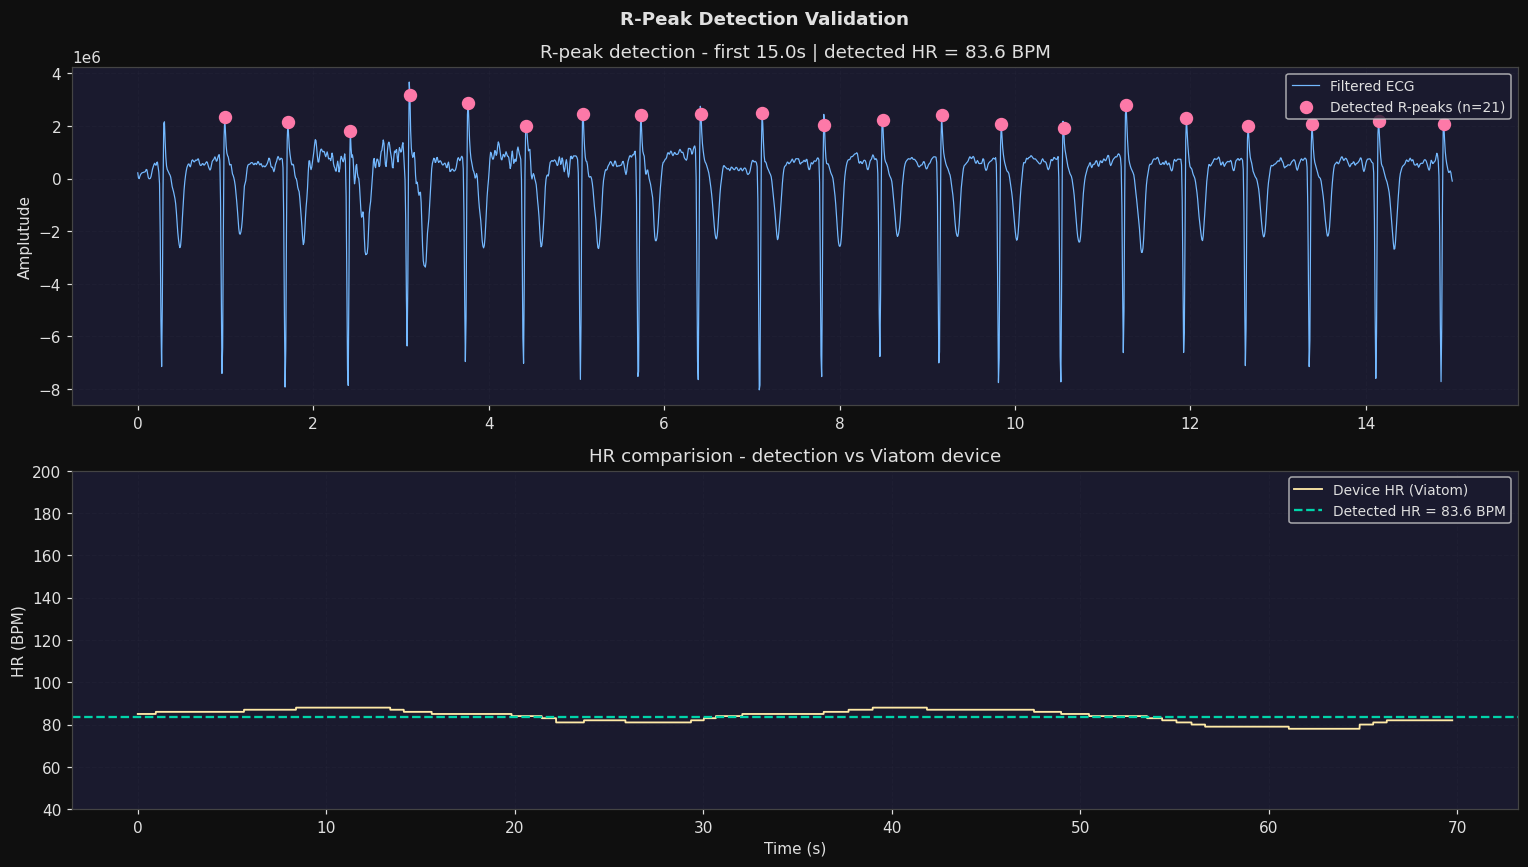

Detected HR : 83.6 BPM
Device HR (mean) : 84.1 BPM
Difference : 0.5 BPM
Good agreement with device HR (< 5 BPM difference)


In [8]:
def detect_r_peaks(ecg_filtered: np.ndarray, ecg_fs: float) -> tuple:
    """
    Detect R-peaks in a filtered ECG signal using NeuroKit2.

    NeuroKit2's ecg_peaks() runs the Pan-Tompkins algorithm by default - 
    the same algorithm used in clinical monitors since 1985. It works by:
        1. Differentiating the signal to emphasise shapr edges (QRS)
        2. Squaring the result to make all values positive
        3. Applying a moving window integrator to find QRS regions
        4. Applying adaptive threshold to find peak locations

    Returns:
        peak_indices : array of sample indices where R-peaks occur
        rr_ms : array of RR intervals in milliseconds
        hr_mean : mean HR in BPM
    """
    # Clean the ECG with NeuroKit2's built-in clearner
    # (additional notch filtering and standarisation)
    ecg_clean = nk.ecg_clean(ecg_filtered, sampling_rate=int(ecg_fs))

    # Detect R-peaks
    peaks_dict, _ = nk.ecg_peaks(ecg_clean, sampling_rate=int(ecg_fs))
    peak_indices = np.where(peaks_dict["ECG_R_Peaks"] == 1)[0]

    if len(peak_indices) < 3:
        return peak_indices, np.array([]), float("nan")

    # Compute RR intervals in milliseconds
    rr_ms = np.diff(peak_indices) / ecg_fs * 1000.0

    # HR from mean RR interval
    # Clinical formula: HR (BPM) == 60,000 / R (ms)
    hr_mean = float(60000.0 / rr_ms.mean())

    return peak_indices, rr_ms, hr_mean

def validate_r_peaks(ecg_filtered: np.ndarray, peak_indices: np.ndarray, hr_detected: float, 
                     hr_device: np.ndarray, ecg_fs: float, window_sec: float = 15.0) -> dict:
    """
    Visual and numerical validation of R-peak detection.

    Plots detected peaks overlaid on the ECG trace.
    Compares  computed HR against the Viatom device HR.

    What correct detection looks like:
        - One marker at the top of each QRS spike
        - No markers on P or T waves (smaller bumps)
        - No double-detected peaks (two markers on one QRS)
        - No missed peaks (QRS with no marker)

    What the comparison should show:
        - Coputed HR ≈ device HR ± 5 BPM is acceptable
        - Larger discrepance -> check sampling rate, signal quality
    """
    n_show = int(window_sec * ecg_fs)
    t = np.arange(n_show) / ecg_fs
    peaks_in_window = peak_indices[peak_indices < n_show]

    fig, axes = plt.subplots(2, 1, figsize=(14,8))
    fig.suptitle("R-Peak Detection Validation", fontsize=12, fontweight="bold")

    # ECG with detected peaks
    ax = axes[0]
    ax.plot(t, ecg_filtered[:n_show], color="#74b9ff", lw=0.8, label="Filtered ECG")
    if len(peaks_in_window) > 0:
        ax.scatter(peaks_in_window / ecg_fs, ecg_filtered[peaks_in_window],
                   color="#fd79a8", s=60, zorder=5, label=f"Detected R-peaks (n={len(peaks_in_window)})")
    ax.set_ylabel("Amplutude")
    ax.set_title(f"R-peak detection - first {window_sec}s | detected HR = {hr_detected:.1f} BPM")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # HR comparison
    ax = axes[1]
    valid_device_hr = hr_device[hr_device > 0]
    t_device = np.linspace(0, len(ecg_filtered) / ecg_fs, len(valid_device_hr))

    ax.plot(t_device, valid_device_hr, color="#ffeaa7", lw=1.2, label="Device HR (Viatom)")
    ax.axhline(hr_detected, color="#00d4aa", lw=1.5, ls="--", label=f"Detected HR = {hr_detected:.1f} BPM")
    ax.set_ylabel("HR (BPM)")
    ax.set_xlabel("Time (s)")
    ax.set_title("HR comparision - detection vs Viatom device")
    ax.set_ylim(40, 200)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/rpeaks_validation.png", bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    # Numerical comparison
    device_hr_mean = float(valid_device_hr.mean())
    hr_diff = abs(hr_detected - device_hr_mean)

    print(f"Detected HR : {hr_detected:.1f} BPM")
    print(f"Device HR (mean) : {device_hr_mean:.1f} BPM")
    print(f"Difference : {hr_diff:.1f} BPM")

    if hr_diff < 5:
        print("Good agreement with device HR (< 5 BPM difference)")
    elif hr_diff < 10:
        print("Moderate discrepancy - check signal quality visually")
    else:
        print("Large discrepancy - likely peak detection failure")

    return {
        "hr_detected" : hr_detected,
        "hr_device_mean" : device_hr_mean,
        "hr_diff" : hr_diff,
        "n_peaks" : len(peak_indices),
    }

# Run on demo recording 
peak_indices_demo, rr_ms_demo, hr_mean_demo = detect_r_peaks(
    ecg_filtered_demo, ecg_fs_demo)

validation_result = validate_r_peaks(
    ecg_filtered_demo,
    peak_indices_demo,
    hr_mean_demo,
    df_viatom_demo["hr_device"].values,
    ecg_fs_demo,
)

## 8. HRV Features from RR Intervals

### From RR intervals to HRV

Computing HRV metrics from RR intervals (the time between consecutive R-peaks in ms) is straightforward arithmetic.

| Metric | Clinical meaning | Formula |
|--------|------------------|---------|
| **RMSSD** | Vagal (parasympathetic) tone| √mean(successive RR differences²)|
| **SDNN** | Overall HRV - total autonomic variability | std(all RR intervals) |
| **pNN50** | % beats where successive RR differs > 50 ms | count (|ΔRR| > 50) / total |
| **mean_RR** | Average beat to beat interval | mean(RR intervals) |

**Why ECG-derived HRV is more reliable than PPG-derived:**
ECG R-peaks are sharp  electrical events - timing precision is ~1 ms.
PPG peaks are the mechanical consequence of cardiac contraction - they are
broder and arrive  100-3000 ms later (pulse transit time). A 10ms timing
is much more accurate. This is why `reference_type: ECG` is being flag in metadata
and give ECG-derived HRV higher confidence wieght during training.



In [9]:
def compute_hrv_features(rr_ms: np.ndarray) -> dict:
    """
    Compute time-domain HRV features from RR intervals.

    Args: 
        rr_ms : array of RR intervals in milliseconds

    Returns dict of HRV features. Returns NaN for all features
    if fewer than 3 RR intervals (insufficient for meaningful HRV).

    Clinical note:
        30 second windows give ~30 beats - sufficient for RMSSD and pNN50
        but not for frequency-domain LF/HF (which needs 5+ minutes).
        Time domain features is beein computed here.
    """
    nan_result = {
        "mean_rr_ms" : float("nan"),
        "sdnn_ms" : float("nan"),
        "rmssd_ms" : float("nan"),
        "pnn50_pct" : float("nan"),
        "hr_mean_bpm" : float("nan"),
        "hr_min_bpm" : float("nan"),
        "hr_max_bpm" : float("nan")
    }

    if len (rr_ms) < 3:
        return nan_result

    # Remove physiologically impossible RR intervals
    # < 300 ms = HR > 200 BPM (not physiological at rest or light exercise)
    # > 2000 ms = HR < 30 BPM (severe bradycardia - unlikely in exercise data)
    rr_clean = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]

    if len(rr_clean) < 3:
        return nan_result

    successive_diffs = np.diff(rr_clean)

    return {
        "mean_rr_ms" : float(rr_clean.mean()),
        "sdnn_ms"    : float(rr_clean.std()),
        "rmssd_ms"   : float(np.sqrt(np.mean(successive_diffs **2))),
        "pnn50_pct"  : float((np.abs(successive_diffs) > 50).mean() * 100),
        "hr_mean_bpm": float(60000.0 / rr_clean.mean()),
        "hr_min_bpm" : float(60000.0 / rr_clean.max()), # min HR == max RR
        "hr_max_bpm" : float(60000.0 / rr_clean.min()), # max HR = min RR
    }

# Compute HRV for demo recording
hrv_demo = compute_hrv_features(rr_ms_demo)

print("HRV features for demo recording:")
print(f"Mean RR : {hrv_demo['mean_rr_ms']:.1f} ms")
print(f"SDNN : {hrv_demo['sdnn_ms']:.1f} ms")
print(f"RMSSD : {hrv_demo['rmssd_ms']:.1f} ms")
print(f"pNN50 : {hrv_demo['pnn50_pct']:.1f} %")
print(f"HR mean : {hrv_demo['hr_mean_bpm']:.1f} BPM")
print(f"HR range : {hrv_demo['hr_min_bpm']:.1f}-{hrv_demo['hr_max_bpm']:.1f} BPM")
print()
print("Clinical reference ranges (resting adult):")
print("RMSSD: 20-50 ms typical | <20 ms = reduced vagal tone")
print("SDNN: 50-100 ms typical")
print("pNN50: 10-30% typical")
print("Note: exercise reduces HRV - expect lower values in ECG-Fitness")

HRV features for demo recording:
Mean RR : 717.8 ms
SDNN : 40.8 ms
RMSSD : 27.3 ms
pNN50 : 7.4 %
HR mean : 83.6 BPM
HR range : 73.6-92.6 BPM

Clinical reference ranges (resting adult):
RMSSD: 20-50 ms typical | <20 ms = reduced vagal tone
SDNN: 50-100 ms typical
pNN50: 10-30% typical
Note: exercise reduces HRV - expect lower values in ECG-Fitness


## 9. Signal Quality Index (SQI)

### Why SQI is the project's key differentiator 

Most rPPG preprocessing pipelines preprocess everything and let the model figure out quality from noisy labels. QualityPhys does something different: it computes an explicit score per clip and discards low-quality clips *before* they ever enter the training set.

What happens without SQI:

* A clip where the subject blocked the camera face with their arm -> rPPG signal is flat -> HR label is meaningless -> model trains on garbage
* A clip where the ECG electrode disconnected -> R-peaks detected on noise -> HRV label is wrong -> model learns wrong features

With SQI these clips are removed programmatically.

### Two SQI scores per clip

**ECG SQI - R-peak regularity**: Measures how regular the detected R-peak spacing is. A clean ECG in sinus rhythm has very regular RR intervals. Motion artefact, electrode noise, and arrhythmias all cause irregular spacing. Score = 1 - (std(RR) / mean(RR)) - higher is more regular.

**rPPG SQI - autocorrelation at expected HR**: Measures whether the extracted rPPG signal has a periodic component at the expected heart rate frequency. A clean rPPG signal should have a strong autocorrelation peak at the lag corresponding to one heartbeat period. Score - normalised autocorrelation at expected lag.

In [10]:
def compute_ecg_sqi(rr_ms: np.ndarray) -> float:
    """
    ECG Signal Quality Index based on RR interval regularity.

    A clean ECG in sinus rhythm has very regular RR invervals.
    The coefficient of variation (std/mean) measures this regularity.

    Score = 1 - min(CV, 1.0)
        CV = 0.0 -> perfectly regular -> SQI = 1.0
        CV = 0.5 -> highly irregular -> SQI = 0.5
        CV ≥ 1.0 -> chaotic -> SQI = 0.0

    Returns NaN if fewer than 3 RR intervals.
    """
    if len(rr_ms) < 3:
        return float("nan")

    rr_clean = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr_clean) < 3:
        return float("nan")

    cv = rr_clean.std() / (rr_clean.mean() + 1e-8)
    return float(1.0 - min(cv, 1.0))

def compute_rppg_sqi(rppg_signal: np.ndarray, hr_bpm: float, fs: float = FPS) -> float:
    """
    rPPG Signal Quality Index based on autocorrelation at expected HR.

    A clean rPPG signal should be periodic at the heart rate.
    Normalised autocorrelation at the lag corresponding to one heartbeat period is being 
    computed here and used as a quality score.

    Args:
        rppg_signal : extracted POS signal, already bandpass filtered
        hr_bpm : expected HR in BPM (from ECG reference)
        fs : sampling frequency

    Score closer to 1.0 = strong periodic component at HR frequency.
    Score near 0 = no clear periodicity = poor signal quality.
    """
    if hr_bpm <= 0 or np.isnan(hr_bpm):
        return float("nan")

    # Expected lag in samples for one heartbeat
    beat_period_samples = int(round(fs * 60.0 / hr_bpm))

    if beat_period_samples >= len(rppg_signal):
        return float("nan")

    # Normalised autocorrelation at heartbeat lag
    s = rppg_signal - rppg_signal.mean()
    autocorr_zero = np.dot(s, s)
    if autocorr_zero < 1e-10:
        return 0.0

    autocorr_lag = np.dot(s[:-beat_period_samples], s[beat_period_samples:])
    sqi = float(autocorr_lag / autocorr_zero)

    # Clip to [0,1] - negative values mean anti-correlated (also bad)
    return float(max(0.0, min(sqi, 1.0)))

# Demo SQI computation
ecg_sqi_demo = compute_ecg_sqi(rr_ms_demo)

print(f"ECG SQI for demo recording : {ecg_sqi_demo:.3f}")
print(f"ECG SQI threshold : {ECG_SQI_THRESHOLD}")
if ecg_sqi_demo >= ECG_SQI_THRESHOLD:
    print("ECG quality acceptable - recording would be kept")
else:
    print("ECG quality below threshold - recording would be discarded")

ECG SQI for demo recording : 0.943
ECG SQI threshold : 0.5
ECG quality acceptable - recording would be kept


## 10. rPPG Extraction (Video -> Signal)

This is the same pipeline like in `rPPG HR Estimation with UBFC data` project with one addition: the YUV -> RGB conversion at the start. The logic is indentical: MediaPipe face mesh, ROI polygon masks, spatial mean RGB, bandpass filter, POS method.

**The POS method reminder**: Projects normalised RGB onto the plane orthogonal to the skin colour vector. Cancels illumination variation (which affects all channels equally) while preserving the pulse signal (which affects R and G differently due to haemoglobin absorption at ~550nm).

In [11]:
# Download MediaPipe face landmarker model if not present
MODEL_PATH = "./face_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading MediaPipe face landmarker model...")
    url = ("https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task")
    urllib.request.urlretrieve(url, MODEL_PATH)
    print("Downloaded")


def get_roi_mask(landmarks, frame_shape: tuple, landmark_indices: list) -> np.ndarray:
    """
    Build binary polygon mask for one ROI from landmark indices.
    """
    h, w = frame_shape[:2]
    pts = np.array([[int(landmarks[idx].x * w), int(landmarks[idx].y * h)] for idx in landmark_indices], dtype=np.int32)
    mask = np.zeros((h,w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask


def extract_roi_signals_yuv(video_path: str, roi_configs: dict, max_frames: int = None) -> dict:
    """
    Extract spatially-averaged RGB time series from facial ROIs.
    Handles YUV -> RGB conversion for ECG-Fitness videos.

    Key difference from rPPG HR Estimation with UBFC data project:
        Phase 1: video is already RGB -> cv2.COLOR_BGR2RGB
        ECG-Fitness: video is YUV 4:2:0 -> cv2.COLOR_BGR2RGB  

    Skips frame 0 as required by ECG-Fitness dataset documentation.
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    roi_sigs = {name: [] for name in roi_configs}
    n_frames = 0
    no_face_ct = 0

    base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
    options = mp_vision.FaceLandmarkerOptions(
        base_options=base_options,
        running_mode=mp_vision.RunningMode.VIDEO,
        num_faces=1,
    )

    with mp_vision.FaceLandmarker.create_from_options(options) as landmarker:
        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and n_frames >= max_frames:
                break

            # Skip frame 0 (dataset documentation requirement)
            if frame_idx ==0:
                frame_idx += 1
                continue

            # YUV -> RGB conversion (ECG-Fitness specific)
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # MediaPipe expects RGB image
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            ts_ms = int((n_frames / fps) * 1000)
            result = landmarker.detect_for_video(mp_image, ts_ms)

            if result.face_landmarks:
                lm = result.face_landmarks[0]
                for name, indices in roi_configs.items():
                    mask = get_roi_mask(lm, rgb_frame.shape, indices)
                    if mask.sum() > 0:
                        r = rgb_frame[:, :, 0][mask == 1].mean()
                        g = rgb_frame[:, :, 1][mask == 1].mean()
                        b = rgb_frame[:, :, 2][mask == 1].mean()
                        roi_sigs[name].append(np.array([r,g,b], dtype=np.float32))
                    else:
                        fallback = (roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32))
                        roi_sigs[name].append(fallback)

            else:
                no_face_ct += 1
                for name in roi_configs:
                    fallback = (roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32))
                    roi_sigs[name].append(fallback)

            n_frames += 1
            frame_idx += 1
    
    cap.release()
    result_dict = {name: np.array(vals) for name, vals in roi_sigs.items()}
    result_dict["__fps__"] = fps
    result_dict["__n_frames__"] = n_frames
    result_dict["__no_face_pct__"] = round(100 * no_face_ct / max(n_frames, 1), 1)
    return result_dict

def extract_pos(clip_roi: dict) -> np.ndarray:
    """
    POS method - average across all ROIs.
    """
    P = np.array([[0, 1, -1], [-2, 1,1]], dtype=np.float64)
    roi_names = [k for k in clip_roi if not k.startswith("__")]
    signals = []

    for name in roi_names:
        C = clip_roi[name].astype(np.float64)
        Cn = C / (C.mean(axis=0) + 1e-8)
        S  = P @ Cn.T
        h = S[0] + (S[0].std() / (S[1].std() + 1e-8)) * S[1]
        signals.append(h)

    combined = np.mean(signals, axis=0)
    filtered = bandpass_filter(combined, FPS, RPPG_BP_LOW, RPPG_BP_HIGH)
    # Z-score normalisation per clip
    mu, sigma = filtered.mean(), filtered.std() + 1e-8
    return ((filtered - mu) / sigma).astype(np.float32)

print("rPPG extraction functions defined.")
print("Run on a single recording with max_frames=300 first to verify:")
print("roi_data = extract_roi_signals_yuv(video_path, ROI_CONFIGS, max_frames=300)")
print("rppg_sig = extract_pos(roi_data)")

rPPG extraction functions defined.
Run on a single recording with max_frames=300 first to verify:
roi_data = extract_roi_signals_yuv(video_path, ROI_CONFIGS, max_frames=300)
rppg_sig = extract_pos(roi_data)


## 11. Full Pipeline: Single Recording

Before running all 17 subjects, run the complete pipeline on one recording and verify every output is physiologicaly plausible.



In [12]:
def process_single_recording(video_path: str, viatom_path: str, sync_path: str, subject_id: int,
                             activity_id: str, max_frames: int = None) -> tuple:
    """
    Run the full preprocessing pipeline on one ECG-Fitness recording.

    Returns a tuple of (result_dict, reason_string).
    result_dict is None if the recording was skipped for any reason.
    reason_string describes why it was skipped, or 'o' if successful.
    This allows the calling loop to log specific skip reasons for analysis.
    """
    
    # Step 0: Brightness pre-screen (fast - avoids processing dark recordings)
    # Runs before any other step to save time on clearly unusable recordings.
    # Low ambient light causes AGC to amplify noise, destroying rPPG SNR.
    brightness  = check_recording_brightness(video_path)

    if brightness < MIN_BRIGHTNESS:
        print(f"SKIP s{subject_id:02d}/a{activity_id}: low light conditions (brightness={brightness:.1f} < {MIN_BRIGHTNESS})")
        return None, f"low_light (brightness={brightness:.1f})"
    
    
    # Step 1: Load ECG reference signal 
    df_viatom = load_viatom_ecg(viatom_path)
    ecg_raw = df_viatom["ecg_raw"].values.astype(np.float32)
    hr_device = df_viatom["hr_device"].values.astype(np.float32)

    dt_ms = np.diff(df_viatom["time_ms"].values).mean()
    ecg_fs = 1000.0 / dt_ms

    # Flat signal check (possible disconnected electrode)
    if ecg_raw.max() - ecg_raw.min() < 50:
        print(f"SKIP s{subject_id:02d}/a{activity_id}: flat ECG signal (disconnected electrode?)")
        return None, "flat_ecg_signal"

    # Step 2: Load sync file
    sync = load_sync_file(sync_path)

    # Step 3: Filter ECG 
    ecg_filtered = bandpass_filter(ecg_raw, ecg_fs, ECG_BP_LOW, ECG_BP_HIGH)

    # Step 4: Detect R-peaks + compute HR/HRV
    peak_indices, rr_ms, hr_mean = detect_r_peaks(ecg_filtered, ecg_fs)

    if np.isnan(hr_mean) or hr_mean < 40 or hr_mean > 220:
        print(f"SKIP s{subject_id:02d}/a{activity_id}: implausible HR ({hr_mean:.1f} BPM)")
        return None, f"implausible_hr ({hr_mean:.1f} BPM)"

    hrv = compute_hrv_features(rr_ms)

    # Step 5: ECG SQI 
    ecg_sqi = compute_ecg_sqi(rr_ms)
    if ecg_sqi < ECG_SQI_THRESHOLD:
        print(f"SKIP s{subject_id:02d}/a{activity_id}: ECG SQI too low ({ecg_sqi:.3f})")
        return None, f"ecg_sqi_low ({ecq_sqi:.3f})"

    # Step 6: Align ECG to video frames via sync file
    # For each video frame, look up the corresponding ECG sample
    # and compute instantaneous HR at that moment
    n_video_frames = min(len(sync), len(ecg_filtered))
    hr_continuous = np.full(n_video_frames, np.nan, dtype=np.float32)

    for frame_i in range(n_video_frames):
        ecg_sample_idx = sync[frame_i]
        # Find nearest R-peak to this ECG sample
        if len(peak_indices) >= 2:
            dists = np.abs(peak_indices - ecg_sample_idx)
            nearest = np.argmin(dists)
            # Compute instantaneous HR from surrounding RR interval
            if nearest < len(rr_ms):
                hr_continuous[frame_i] = 60000.0 / rr_ms[nearest]

    # Step 7: Extract rPPG signal from video
    roi_data = extract_roi_signals_yuv(video_path, ROI_CONFIGS, max_frames=max_frames)
    n_frames = roi_data["__n_frames__"]
    no_face = roi_data["__no_face_pct__"]

    if no_face > 20.0:
        print(f"SKIP s{subject_id:02d}/a{activity_id}: too many frames without face ({no_face:.1f}%)")
        return None, f"no_face ({no_face:.1f}%)"

    rppg_signal = extract_pos(roi_data)

    # Stack ROI RGB: [T, 3_ROIs, 3_ch]
    roi_names = [k for k in roi_data if not k.startswith("__")]
    roi_rgb = np.stack([roi_data[name] for name in roi_names], axis=1).astype(np.float32)   # [T, 3, 3]

    # Step 8: rPPG SQI 
    rppg_sqi = compute_rppg_sqi(rppg_signal, hr_mean, FPS)
    if rppg_sqi < RPPG_SQI_THRESHOLD:
        print(f"SKIP s{subject_id:02d}/a{activity_id}: rPPG SQI too low ({rppg_sqi:.3f})")
        return None, f"rppg_sqi_low ({rppg_sqi:.3f})"

    # Step 9: Align signal lengths 
    # All signals must have the same length (minimum of all)
    T = min(len(rppg_signal), len(hr_continuous), roi_rgb.shape[0])
    rppg_signal = rppg_signal[:T]
    hr_continuous = hr_continuous[:T]
    roi_rgb = roi_rgb[:T]

    # Align reference ECG to video frame rate by interpolation
    ecg_resampled = np.interp(
        np.linspace(0, 1, T),
        np.linspace(0, 1, len(ecg_filtered)),
        ecg_filtered
    ).astype(np.float32)

    print(f"s{subject_id:02d}/a{activity_id} frames={T}  HR={hr_mean:.1f} ECG_SQI={ecg_sqi:.2f}  rPPG_SQI={rppg_sqi:.2f} no_face={no_face:.1f}%")

    result =  {
        # Signals
        "rppg_signal" : rppg_signal, # [T] float32
        "roi_rgb" : roi_rgb, # [T, 3, 3] float32
        "reference_signal" : ecg_resampled, # [T] float32
        "hr_continuous" : hr_continuous, # [T] float32
        "rr_intervals" : rr_ms.astype(np.float32),  # [N_beats]

        # Scalar labels
        "hr_mean" : float(hr_mean),
        "rmssd_ms" : hrv["rmssd_ms"],
        "sdnn_ms" : hrv["sdnn_ms"],
        "pnn50_pct" : hrv["pnn50_pct"],

        # Metadata
        "subject_id" : subject_id,
        "activity_id" : activity_id,
        "activity_name" : ACTIVITY_NAMES.get(activity_id, "unknown"),
        "dataset" : DATASET_NAME,
        "reference_type" : "ECG",
        "n_frames"  : T,
        "fps" : FPS,
        "ecg_sqi" : float(ecg_sqi),
        "rppg_sqi" : float(rppg_sqi),
        "no_face_pct" : float(no_face),
    }
    return result, "ok"


# Test on first recording — use max_frames=300 (~10s) for a quick sanity check
print("Running single-recording pipeline test (first 300 frames)...")
demo_result, demo_reason  = process_single_recording(
    first_recording["video_path"],
    first_recording["viatom_path"],
    first_recording["sync_path"],
    first_recording["subject_id"],
    first_recording["activity_id"],
    max_frames=300,
)

if demo_result is not None:
    print()
    print("Output shapes:")
    for key, val in demo_result.items():
        if hasattr(val, "shape"):
            print(f"{key:<20}: {val.shape}")
        elif isinstance(val, float):
            print(f"{key:<20}: {val:.3f}")
        else:
            print(f"{key:<20}: {val}")
else:
    print(f"Demo recording skipped — reason: {demo_reason}")

Running single-recording pipeline test (first 300 frames)...
SKIP s00/a01: rPPG SQI too low (0.344)
Demo recording skipped — reason: rppg_sqi_low (0.344)


## 12. Write to HDF5

HDF5 is a hierarchical file format. It handles arrays of different lengths natively (unlike NumPy), loads subsets without reading the whole file, and stores metadata (attributes) alongside data arrays.

**Why not NumPy .npy?** NumPy requires all arrays to be the same shape. Recordings have different durations and different numbers of detected beats. With NumPy everything need to be padded to the same length (wasting space) or store one file per recording. HDF% stores each recording as a group with its own arrays of any length.

**Schema:**

```
ecg_fitness.h5
└── subjects/
    └── 00/
        └── recordings/
            └── 01/   ← activity ID
                ├── rppg_signal       [T]
                ├── roi_rgb           [T, 3, 3]
                ├── reference_signal  [T]
                ├── hr_continuous     [T]
                ├── rr_intervals      [N_beats]
                └── attrs: hr_mean, rmssd, sqi scores, metadata...
```

In [13]:
def write_recording_to_hdf5(h5_file: h5py.File, result: dict) -> None:
    """
    Write one preprocessed recording to the HDF5 file.

    Creates the group hierarchy if it does not exist.
    Skips writing if the recording group already exists
    (allows resuming interrupted processing runs).
    """
    subj = f"{result['subject_id']:02d}"
    act = result["activity_id"]
    path = f"subjects/{subj}/recordings/{act}"

    # Skip if already processed (resume-safe)
    if path in h5_file:
        print(f"Already exists: {path} - skipping")
        return

    grp = h5_file.require_group(path)

    # Signal arrays
    grp.create_dataset("rppg_signal", data=result["rppg_signal"], compression="gzip", compression_opts=4)
    grp.create_dataset("roi_rgb", data=result["roi_rgb"], compression="gzip", compression_opts=4)
    grp.create_dataset("reference_signal", data=result["reference_signal"], compression="gzip", compression_opts=4)
    grp.create_dataset("hr_continuous", data=result["hr_continuous"], compression="gzip", compression_opts=4)
    grp.create_dataset("rr_intervals", data=result["rr_intervals"], compression="gzip", compression_opts=4)

    # Scalar metadata as HDF5 attributes
    # Attributes are stored in the group header - fast to read without loading the full signal arrays 
    attrs = {
        "subject_id" : result["subject_id"],
        "activity_id" : result["activity_id"],
        "activity_name" : result["activity_name"],
        "dataset" : result["dataset"],
        "reference_type" : result["reference_type"],
        "n_frames" : result["n_frames"],
        "fps" : result["fps"],
        "hr_mean" : result["hr_mean"],
        "rmssd_ms" : result["rmssd_ms"] if not np.isnan(result["rmssd_ms"]) else -1.0,
        "sdnn_ms" : result["sdnn_ms"] if not np.isnan(result["sdnn_ms"]) else -1.0,
        "pnn50_pct" : result["pnn50_pct"] if not np.isnan(result["pnn50_pct"]) else -1.0,
        "ecg_sqi" : result["ecg_sqi"],
        "rppg_sqi" : result["rppg_sqi"],
        "no_face_pct" : result["no_face_pct"],
    }
    for key, value in attrs.items(): grp.attrs[key] = value

def initialise_hdf5(output_path: str) -> h5py.File:
    """
    Create (or open existing) HDF5 file with top-level metadata.
    Mode 'a' = append - safe to reopen without overwriting existing data.
    """
    h5 = h5py.File(output_path, "a")
    
    # Write top-level metadata once
    if "metadata" not in h5:
        meta = h5.require_group("metadata")
        meta.attrs["dataset_name"] = DATASET_NAME
        meta.attrs["preprocessing_version"] = "1.0"
        meta.attrs["fps"] = FPS
        meta.attrs["rppg_bp_low"] = RPPG_BP_LOW
        meta.attrs["rppg_bp_high"] = RPPG_BP_HIGH
        meta.attrs["ecg_bp_low"] = ECG_BP_LOW
        meta.attrs["ecg_bp_high"] = ECG_BP_HIGH
        meta.attrs["valid_activities"] = str(VALID_ACTIVITIES)
        meta.attrs["rppg_sqi_threshold"] = RPPG_SQI_THRESHOLD
        meta.attrs["ecg_sqi_threshold"] = ECG_SQI_THRESHOLD

    return h5

# Write demo result to HDF5
print(f"Writning to: {HDF5_PATH}")

if demo_result:
    with initialise_hdf5(HDF5_PATH) as h5:
        write_recording_to_hdf5(h5, demo_result)
    print("Demo recording written successfully")

    # Verify by reading back
    with h5py.File(HDF5_PATH, "r") as h5:
        subj = f"{demo_result['subject_id']:02d}"
        act = demo_result["activity_id"]
        grp = h5[f"subjects/{subj}/recordings/{act}"]
        print()
        print("Readback verification:")
        for ds_name in grp.keys():
            print(f"{ds_name:<20}: {grp[ds_name].shape}")
        print("Attributes:")
        for k, v in grp.attrs.items():
            print(f"{k:<20}: {v}")
    

Writning to: E:/QualityPhys\ecg_fitness.h5


## 13. Process All Subjects

This is the main processing loop. It iterates over all recordings, runs the full pipeline, and writes each result to HDF5.

**Expected runtime**: ~15-20 minutes per subject on a modern CPU. Total: ~4-5 hours for all 17 subjects x 4 activites.

**Resume safety**: If the run is interrupdted, re-running will skip already-completed recordings (`write_recording_to_hdf5` checks for existing groups before writing).

**Progress monitoring**: A summary CSV is saved alongside the HDF5 so you can inspect which recordings passed/failed without openinng the HDF5.

In [14]:
def process_all_subjects(df_inventory: pd.DataFrame, hdf5_path: str) -> pd.DataFrame:
    """
    Process all valid ECG-Fitness recordings and write to HDF5.

    Returns a DataFrame summarising which recordings were processed, 
    which were skipped, and the specific reason for each skip.
    """
    log_rows = []

    with initialise_hdf5(hdf5_path) as h5:
        total = len(df_inventory[df_inventory["complete"]])

        for i, (_, row) in enumerate(df_inventory[df_inventory["complete"]].iterrows()):
            subj_id = row["subject_id"]
            act_id = row["activity_id"]
            print(f"[{i+1:03d}/{total}] Subject {subj_id:02d} Activity {act_id} ({row['activity_name']})")

            result, reason = process_single_recording(
                row["video_path"],
                row["viatom_path"],
                row["sync_path"],
                subj_id,
                act_id,
                max_frames=None, # full recording
            )

            if result is not None:
                write_recording_to_hdf5(h5, result)
                log_rows.append({
                    "subject_id" : subj_id,
                    "activity_id" : act_id,
                    "status" : "processed",
                    "skip_reason": "ok",
                    "hr_mean" : result["hr_mean"],
                    "ecg_sqi" : result["ecg_sqi"],
                    "rppg_sqi" : result["rppg_sqi"],
                    "n_frames" : result["n_frames"],
                    "no_face_pct" :  result["no_face_pct"],
                })
            else:
                log_rows.append({
                    "subject_id" : subj_id,
                    "activity_id" : act_id,
                    "status" : "skipped",
                    "skip_reason": reason,
                    "hr_mean" : np.nan,
                    "ecg_sqi" : np.nan,
                    "rppg_sqi" : np.nan,
                    "n_frames" : 0,
                    "no_face_pct" : np.nan,
                })

    df_log = pd.DataFrame(log_rows)
    log_path = os.path.join(OUTPUT_DIR, f"processing_log_{DATASET_NAME}.csv")
    df_log.to_csv(log_path, index=False)

    print()
    print("=" * 50)
    print("Processing complete")
    print("=" * 50)
    processed = (df_log["status"] == "processed").sum()
    skipped = (df_log["status"] == "skipped").sum()
    print(f"Processed : {processed}")
    print(f"Skipped : {skipped}")
    print()

    if "skip_reason" in df_log.columns:
        skip_reasons = df_log[df_log["status"] == "skipped"]["skip_reason"].str.split(" ").str[0].value_counts()
        print("Skip reasons:")
        for reason, count in skip_reasons.items():
            print(f"{reason:<30}: {count}")
        
    print()
    print(f"Log saved : {log_path}")
    print(f"HDF5 saved : {hdf5_path}")
    return df_log

# Uncomment to run the full pipeline
# Run the single-recording test and verify outputs first.
# Only run the full pipeline once you are confident the pipeline is correct.

df_log = process_all_subjects(df_inventory, HDF5_PATH)
print(df_log.to_string(index=False))

print("Full pipeline ready.")

[001/68] Subject 00 Activity 01 (rowing_ambient)
s00/a01 frames=1799  HR=83.6 ECG_SQI=0.94  rPPG_SQI=0.48 no_face=0.0%
Already exists: subjects/00/recordings/01 - skipping
[002/68] Subject 00 Activity 02 (speaking_ambient)
SKIP s00/a02: rPPG SQI too low (0.000)
[003/68] Subject 00 Activity 05 (elliptical_ambient)
SKIP s00/a05: rPPG SQI too low (0.000)
[004/68] Subject 00 Activity 06 (bike_ambient)
SKIP s00/a06: rPPG SQI too low (0.104)
[005/68] Subject 01 Activity 01 (rowing_ambient)
SKIP s01/a01: rPPG SQI too low (0.352)
[006/68] Subject 01 Activity 02 (speaking_ambient)
SKIP s01/a02: rPPG SQI too low (0.105)
[007/68] Subject 01 Activity 05 (elliptical_ambient)
SKIP s01/a05: rPPG SQI too low (0.088)
[008/68] Subject 01 Activity 06 (bike_ambient)
SKIP s01/a06: rPPG SQI too low (0.293)
[009/68] Subject 02 Activity 01 (rowing_ambient)
s02/a01 frames=1799  HR=60.5 ECG_SQI=0.92  rPPG_SQI=0.42 no_face=0.0%
Already exists: subjects/02/recordings/01 - skipping
[010/68] Subject 02 Activity 02 

## 14. Post Processing Validation

After processing all subjects, verify the HDF5 file is internally consistent and the statistics are physiologically plausible.


In [15]:
def validate_hdf5(hdf5_path: str) -> None:
    """
    Read back all recordings from HDF5 and verify:
        1. All expected arrays are present and have correct shapes
        2. HR distribution is physiologically plausible
        3. SQI scores are above threshold (sanity check - shouldalways pass 
           since we filtered before writing, but verifies nothing was corrupted)
        4. No recordings with all-NaN arrays
    """
    records = []

    with h5py.File(hdf5_path, "r") as h5:
        print(f"Top-level groups: {list(h5.keys())}")
        print(f"Metadata:")
        for key, value in h5["metadata"].attrs.items():
            print(f"{key} : {value}")
        print()

        for subj_key in sorted(h5["subjects"].keys()):
            for act_key in sorted(h5[f"subjects/{subj_key}/recordings"].keys()):
                grp = h5[f"subjects/{subj_key}/recordings/{act_key}"]
                attrs = dict(grp.attrs)

                # Shape checks
                T = grp["rppg_signal"].shape[0]
                assert grp["roi_rgb"].shape[0] == T, f"roi_rgb length mismatch in {subj_key}/{act_key}"
                assert grp["reference_signal"].shape[0] == T, f"reference_signal length mismatch in {subj_key}/{act_key}"

                records.append({
                    "subject_id" : attrs.get("subject_id"),
                    "activity" : attrs.get("activity_name"),
                    "n_frames" : T,
                    "hr_mean" : attrs.get("hr_mean"),
                    "rmssd_ms" : attrs.get("rmssd_ms"),
                    "ecg_sqi" : attrs.get("ecg_sqi"),
                    "rppg_sqi" : attrs.get("rppg_sqi"),
                    "n_beats" : grp["rr_intervals"].shape[0],
                })

    df = pd.DataFrame(records)
    print(f"Total recordings validated: {len(df)}")
    print()

    # HR distribution
    valid_hr = df["hr_mean"].dropna()
    valid_hr_mean = valid_hr.mean()
    valid_hr_min = valid_hr.min()
    valid_hr_max = valid_hr.max()
    print(f"HR distribution:")
    print(f"Mean : {valid_hr_mean:.1f} BPM")
    print(f"Range : {valid_hr_min:.1f}-{valid_hr_max:.1f} BPM")
    print(f"ExpecteD: 56-159 BPM (from dataset paper)")
    print()

    # SQI check
    ecg_mean = df["ecg_sqi"].mean()
    ecg_min = df["ecg_sqi"].min()
    rppg_mean = df["rppg_sqi"].mean()
    rppg_min = df["rppg_sqi"].min()
    print(f"SQI scores:")
    print(f"ECG SQI mean: {ecg_mean:.3f} min: {ecg_min:.3f}")
    print(f"rPPG SQI mean: {rppg_mean:.3f} min: {rppg_min:.3f}")
    print()

    # Activity distribution
    print("Recordings per activity:")
    print(df["activity"].value_counts().to_string())

    return df

# Run validation after full processing
df_validation = validate_hdf5(HDF5_PATH)

print("Validation function ready.")
                

Top-level groups: ['metadata', 'subjects']
Metadata:
dataset_name : ecg_fitness
ecg_bp_high : 40.0
ecg_bp_low : 0.5
ecg_sqi_threshold : 0.5
fps : 30.0
preprocessing_version : 1.0
rppg_bp_high : 3.5
rppg_bp_low : 0.7
rppg_sqi_threshold : 0.4
valid_activities : ['01', '02', '05', '06']

Total recordings validated: 14

HR distribution:
Mean : 86.7 BPM
Range : 55.4-119.9 BPM
ExpecteD: 56-159 BPM (from dataset paper)

SQI scores:
ECG SQI mean: 0.916 min: 0.859
rPPG SQI mean: 0.493 min: 0.404

Recordings per activity:
activity
rowing_ambient        9
bike_ambient          2
elliptical_ambient    2
speaking_ambient      1
Validation function ready.
